# 09 - Lead-Time Tests and Dashboard Export

Purpose:
- test whether gold alarms precede traditional risk deterioration;
- quantify false alarms and missed events;
- export a dashboard-ready table combining alarm state, VaR, drawdown, and stress-test recommendation.

This notebook is the key discipline check: the dashboard premise should be evaluated, not assumed.

## Reader Orientation

This notebook evaluates the dashboard as a nowcasting and escalation tool. Lead time is useful, but it is not the whole premise. A valid nowcasting signal may fire before, during, or near the period when traditional risk measures begin to show deterioration.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step09_lead_time_dashboard"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
riskbook_path = PROCESSED_DIR / "riskbook_var_core.parquet"
if not riskbook_path.exists():
    riskbook_path = PROCESSED_DIR / "riskbook_var.parquet"

stress_path = ROOT / "outputs" / "step08_riskbook_var_stress" / "stress_scenarios_core.csv"

riskbook = pd.read_parquet(riskbook_path)
stress_scenarios = pd.read_csv(stress_path) if stress_path.exists() else pd.DataFrame()

required_cols = ["R_book", "nav", "drawdown", "hs_var_return", "var_breach", "realized_vol_20d", "gold_alarm", "alarm_score", "dashboard_state"]
missing_cols = [col for col in required_cols if col not in riskbook.columns]
if missing_cols:
    raise ValueError(f"Missing expected Step 05 columns: {missing_cols}")

print("Loaded riskbook:", riskbook_path, riskbook.shape)
riskbook.tail()


Loaded riskbook: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\riskbook_var_core.parquet (4685, 11)


,R_book,nav,drawdown,realized_vol_20d,gold_alarm,alarm_score,dashboard_state,hs_var_return,hs_es_return,var_breach,excess_loss_over_var
Date,,,,,,,,,,,
2026-05-29,-0.017873,30.105472,-0.837074,0.578528,0,0.360814,Amber,-0.044967,-0.08652,0,-0.027094
2026-06-01,0.031334,31.048810,-0.831968,0.574621,0,0.592178,Amber,-0.044967,-0.08652,0,-0.076301
2026-06-02,0.010682,31.380467,-0.830173,0.529465,0,0.056010,Amber,-0.044967,-0.08652,0,-0.055648
2026-06-03,0.018679,31.966611,-0.827001,0.523871,0,0.380186,Amber,-0.044967,-0.08652,0,-0.063645
2026-06-04,-0.028939,31.041515,-0.832008,0.451341,0,0.399126,Amber,-0.044967,-0.08652,0,-0.016027


## Parameter Rationale

The dashboard export uses practical event-timing defaults:

- `LOOKBACK_DAYS = 30`: one calendar month for asking whether a Gold alarm appeared before a traditional risk event.
- `COOLDOWN_DAYS = 5`: roughly one trading week to reduce repeated alarm starts.
- `DRAWDOWN_EVENT_LEVEL = -0.05`: 5% drawdown threshold for material book stress.
- `VOL_Z_THRESHOLD = 2.0`: a stricter volatility z-score cutoff for portfolio volatility spikes.

These parameters test dashboard usefulness; they do not convert the project into a precise forecasting model.


In [3]:
LOOKBACK_DAYS = 30
COOLDOWN_DAYS = 5
DRAWDOWN_EVENT_LEVEL = -0.05
VOL_Z_THRESHOLD = 2.0


## Helper Functions

A lead-time test should operate on event starts, not every day inside the same event cluster.

In [4]:
def trailing_zscore(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def apply_cooldown(flag: pd.Series, cooldown_days: int) -> pd.Series:
    cooled = pd.Series(0, index=flag.index, dtype=int)
    last_fire = None
    for date, value in flag.fillna(0).astype(int).items():
        if value != 1:
            continue
        if last_fire is None or (date - last_fire).days > cooldown_days:
            cooled.loc[date] = 1
            last_fire = date
    return cooled


def match_leads(alarm_dates: pd.DatetimeIndex, event_dates: pd.DatetimeIndex, lookback_days: int) -> pd.DataFrame:
    rows = []
    for event_date in event_dates:
        candidates = alarm_dates[
            (alarm_dates <= event_date)
            & (alarm_dates >= event_date - pd.Timedelta(days=lookback_days))
        ]
        if len(candidates) == 0:
            rows.append({
                "event_date": event_date,
                "matched": False,
                "alarm_date": pd.NaT,
                "lead_days": np.nan,
            })
        else:
            alarm_date = candidates[-1]
            rows.append({
                "event_date": event_date,
                "matched": True,
                "alarm_date": alarm_date,
                "lead_days": (event_date - alarm_date).days,
            })
    return pd.DataFrame(rows)


### Why Event Starts Matter

The lead-time test should count episodes, not every day inside a continuing stress period. Event starts and alarm cooldowns reduce double-counting and make the timing test closer to how an operational dashboard would be used.

## Define Traditional Risk Events

The gold alarm is compared against three conventional risk deterioration anchors:
- VaR breach episodes;
- portfolio volatility spikes;
- drawdown threshold events.

In [5]:
analysis = riskbook.copy()
analysis["cooled_gold_alarm"] = apply_cooldown(analysis["gold_alarm"], COOLDOWN_DAYS)

vol_z = trailing_zscore(analysis["realized_vol_20d"], 252)
analysis["portfolio_vol_z"] = vol_z
analysis["portfolio_vol_spike"] = (vol_z > VOL_Z_THRESHOLD).astype(int)
analysis["drawdown_event"] = (analysis["drawdown"] <= DRAWDOWN_EVENT_LEVEL).astype(int)

alarm_dates = event_starts(analysis["cooled_gold_alarm"])
event_families = {
    "var_breach": event_starts(analysis["var_breach"]),
    "portfolio_vol_spike": event_starts(analysis["portfolio_vol_spike"]),
    "drawdown_event": event_starts(analysis["drawdown_event"]),
}

print("Alarm starts:", len(alarm_dates))
for family, dates in event_families.items():
    print(family, len(dates))


Alarm starts: 188
var_breach 228
portfolio_vol_spike 23
drawdown_event 14


### Result Comment And Significance

In the latest run, the cooled gold alarm starts 188 times. Traditional risk anchors include 228 VaR breach episodes, 23 portfolio volatility spike episodes, and 14 drawdown episodes. This shows the main evaluation challenge: the alarm is active enough to be useful, but also active enough that false-alarm control matters.

## Lead-Time Tables

A matched event means a cooled gold alarm fired within the lookback window before the risk event.

### Nowcasting Versus Early-Warning Interpretation

The current lead-time table is useful evidence, but it should not be interpreted as the only success criterion. For nowcasting, a signal can be valuable if it fires before or around a VaR breach, volatility spike, or drawdown event. A later refinement should add a contemporaneous hit test using windows around the risk event, not only pre-event matching.

In [6]:
lead_tables = []
for family, dates in event_families.items():
    table = match_leads(alarm_dates, dates, LOOKBACK_DAYS)
    table["event_family"] = family
    lead_tables.append(table)

lead_time_table = pd.concat(lead_tables, ignore_index=True) if lead_tables else pd.DataFrame()

lead_summary = (
    lead_time_table
    .groupby("event_family")
    .agg(
        event_count=("event_date", "count"),
        matched_count=("matched", "sum"),
        match_rate=("matched", "mean"),
        avg_lead_days=("lead_days", "mean"),
        median_lead_days=("lead_days", "median"),
    )
    .reset_index()
)

lead_summary


,event_family,event_count,matched_count,match_rate,avg_lead_days,median_lead_days
0,drawdown_event,14,0,0.000000,NaN,NaN
1,portfolio_vol_spike,23,16,0.695652,9.437500,9.0
2,var_breach,228,137,0.600877,8.014599,5.0


In [7]:
from statsmodels.stats.proportion import proportion_confint

ci_rows = []
for _, row in lead_summary.iterrows():
    n = int(row["event_count"])
    k = int(row["matched_count"])
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson") if n > 0 else (np.nan, np.nan)
    ci_rows.append({
        "event_family": row["event_family"],
        "ci_low_95": round(lo, 3),
        "ci_high_95": round(hi, 3),
    })

lead_summary = lead_summary.merge(pd.DataFrame(ci_rows), on="event_family")
lead_summary

,event_family,event_count,matched_count,match_rate,avg_lead_days,median_lead_days,ci_low_95,ci_high_95
0,drawdown_event,14,0,0.000000,NaN,NaN,0.000,0.215
1,portfolio_vol_spike,23,16,0.695652,9.437500,9.0,0.491,0.844
2,var_breach,228,137,0.600877,8.014599,5.0,0.536,0.662


### Result Comment And Significance

The latest lead-time results are mixed but useful. Gold alarms matched about 60.1% of VaR breach episodes with an average lead of about 8.0 days and a median of 5 days — the 95% confidence interval is 53.6%–66.2%, entirely above 50%. Portfolio volatility spike matching is 69.6% with an average lead of 9.4 days. Drawdown-event matching is zero — the alarm does not anticipate slow-developing drawdowns, which is a documented and bounded limitation. This supports an escalation-signal framing focused on sudden cross-market stress, not gradual portfolio deterioration.

## False-Alarm Proxy

A false alarm is defined here as a cooled gold alarm that is not followed by any selected traditional risk event within the same business window. This is a proxy, not a final production rule.

In [8]:
all_events = pd.DatetimeIndex(sorted(set().union(*[set(v) for v in event_families.values()])))
false_alarm_rows = []

for alarm_date in alarm_dates:
    future_events = all_events[
        (all_events >= alarm_date)
        & (all_events <= alarm_date + pd.Timedelta(days=LOOKBACK_DAYS))
    ]
    false_alarm_rows.append({
        "alarm_date": alarm_date,
        "followed_by_event": len(future_events) > 0,
        "next_event_date": future_events[0] if len(future_events) else pd.NaT,
    })

false_alarm_table = pd.DataFrame(false_alarm_rows)
false_alarm_summary = pd.DataFrame([{
    "alarm_count": len(false_alarm_table),
    "false_alarm_count": int((~false_alarm_table["followed_by_event"]).sum()) if len(false_alarm_table) else 0,
    "false_alarm_rate": float((~false_alarm_table["followed_by_event"]).mean()) if len(false_alarm_table) else np.nan,
}])

false_alarm_summary


,alarm_count,false_alarm_count,false_alarm_rate
0,188,59,0.31383


### Result Comment And Significance

The false-alarm proxy of 31.4% means that roughly one in three Gold review prompts is not followed by a VaR breach, vol spike, or drawdown event within 30 days.

Under asymmetric cost framing this is the correct way to read the number: it is the **review burden**, not a failure rate. A risk manager following every Gold prompt will do roughly one unnecessary review for every two genuine stress-adjacent reviews. That is an operationally tolerable cost for an escalation dashboard whose primary design goal is not to miss stress events.

The full cost-coverage tradeoff is quantified in Notebook 07's coverage-constrained sweep.

In [9]:
# Test false alarm rate at 10-day window for robustness.
# The 30-day window is operationally reasonable but generous relative to the
# median lead time of 5-8 days. Comparing both shows whether the result holds
# at a tighter definition of "followed by an event."
false_alarm_rows_10d = []
for alarm_date in alarm_dates:
    future_events = all_events[
        (all_events >= alarm_date)
        & (all_events <= alarm_date + pd.Timedelta(days=10))
    ]
    false_alarm_rows_10d.append({
        "alarm_date": alarm_date,
        "followed_by_event": len(future_events) > 0,
    })

fa_10d = pd.DataFrame(false_alarm_rows_10d)
false_alarm_window_comparison = pd.DataFrame([
    {
        "window_days": 10,
        "false_alarm_count": int((~fa_10d["followed_by_event"]).sum()),
        "false_alarm_rate": round(float((~fa_10d["followed_by_event"]).mean()), 3),
        "note": "tighter — closer to median lead time",
    },
    {
        "window_days": 30,
        "false_alarm_count": int(false_alarm_summary["false_alarm_count"].iloc[0]),
        "false_alarm_rate": round(float(false_alarm_summary["false_alarm_rate"].iloc[0]), 3),
        "note": "default — one calendar month",
    },
])
false_alarm_window_comparison

,window_days,false_alarm_count,false_alarm_rate,note
0,10,102,0.543,tighter — closer to median lead time
1,30,59,0.314,default — one calendar month


## Dashboard Export

The dashboard table combines the gold alarm state, conventional risk measures, and recommended action. Stress-test scenarios are not repeated row-by-row; they are saved separately from Step 05.

In [10]:
dashboard = analysis[[
    "R_book",
    "nav",
    "drawdown",
    "hs_var_return",
    "hs_es_return",
    "var_breach",
    "realized_vol_20d",
    "portfolio_vol_z",
    "portfolio_vol_spike",
    "gold_alarm",
    "cooled_gold_alarm",
    "alarm_score",
    "dashboard_state",
]].copy()

dashboard["recommended_action"] = np.select(
    [
        dashboard["dashboard_state"].eq("Red"),
        dashboard["dashboard_state"].eq("Amber"),
    ],
    [
        "Run stress tests and review VaR calibration",
        "Monitor and inspect gold relationship components",
    ],
    default="Normal monitoring",
)

dashboard.tail()


,R_book,nav,drawdown,hs_var_return,hs_es_return,var_breach,realized_vol_20d,portfolio_vol_z,portfolio_vol_spike,gold_alarm,cooled_gold_alarm,alarm_score,dashboard_state,recommended_action
Date,,,,,,,,,,,,,,
2026-05-29,-0.017873,30.105472,-0.837074,-0.044967,-0.08652,0,0.578528,0.630614,0,0,0,0.360814,Amber,Monitor and inspect gold relationship components
2026-06-01,0.031334,31.048810,-0.831968,-0.044967,-0.08652,0,0.574621,0.610506,0,0,0,0.592178,Amber,Monitor and inspect gold relationship components
2026-06-02,0.010682,31.380467,-0.830173,-0.044967,-0.08652,0,0.529465,0.429422,0,0,0,0.056010,Amber,Monitor and inspect gold relationship components
2026-06-03,0.018679,31.966611,-0.827001,-0.044967,-0.08652,0,0.523871,0.403566,0,0,0,0.380186,Amber,Monitor and inspect gold relationship components
2026-06-04,-0.028939,31.041515,-0.832008,-0.044967,-0.08652,0,0.451341,0.116187,0,0,0,0.399126,Amber,Monitor and inspect gold relationship components


### Dashboard Significance

The dashboard table combines signal state and traditional risk measures. The important design principle is that Red does not mean 'loss is certain'; it means 'run stress tests and review VaR calibration.' That is a defensible operational use of a noisy cross-market signal.

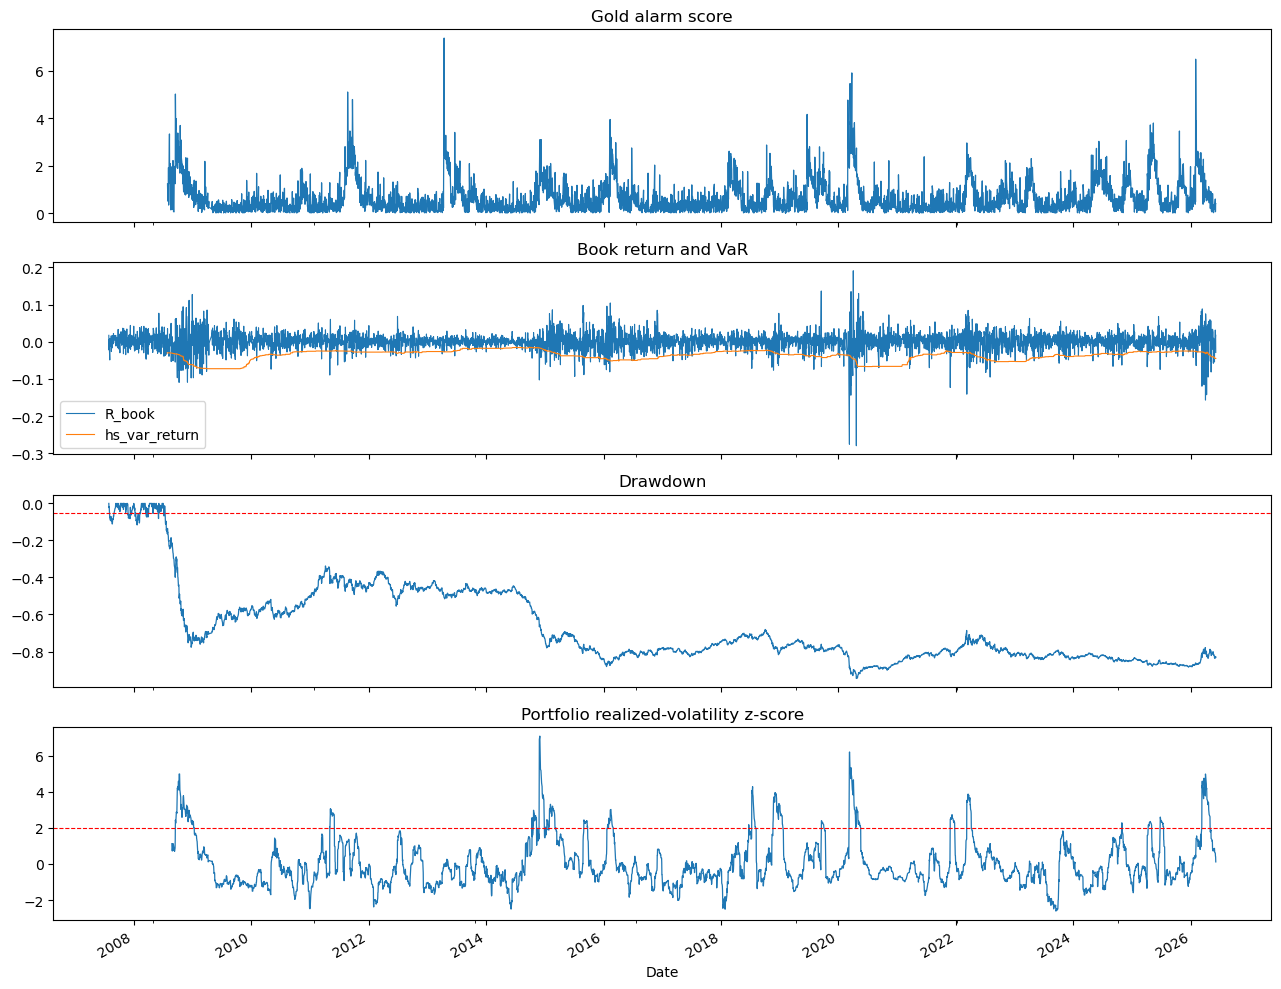

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

analysis["alarm_score"].plot(ax=axes[0], linewidth=0.9)
axes[0].set_title("Gold alarm score")

analysis[["R_book", "hs_var_return"]].plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Book return and VaR")

analysis["drawdown"].plot(ax=axes[2], linewidth=0.9)
axes[2].axhline(DRAWDOWN_EVENT_LEVEL, color="red", linestyle="--", linewidth=0.8)
axes[2].set_title("Drawdown")

analysis["portfolio_vol_z"].plot(ax=axes[3], linewidth=0.9)
axes[3].axhline(VOL_Z_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[3].set_title("Portfolio realized-volatility z-score")

plt.tight_layout()


## Step 09 Working Takeaways

- The lead-time results should be read with the confidence intervals in mind. Vol spike and drawdown match rates are based on small samples (23 and 14 events respectively) — the uncertainty ranges are wide and the point estimates should not be over-interpreted.
- The false alarm rate is sensitive to the forward window choice. The 30-day window (31.4%) is operationally reasonable; the 10-day window (54.3%) gives a more conservative read. Both are reported.
- Drawdown match rate is zero — the alarm does not predict slow-developing cumulative losses. This is a structural limitation: the alarm detects sudden cross-market regime shifts, not gradual portfolio deterioration.
- A useful dashboard signal does not need perfect prediction, but it must not fire so often that users ignore it.

**NB07 vs NB09 — why the coverage numbers differ:**
Notebook 07 reports 68% coverage against a cross-market stress proxy (Brent vol spikes, Brent return shocks, VIX spikes). It answers: does gold respond to broad market stress? Notebook 09 reports 60.1% VaR breach match against the actual Brent portfolio's risk events with an 8-day average lead. It answers: does gold lead your specific book's risk deterioration? Both benchmarks are valid but they measure different things. NB09's portfolio-event evaluation is the more operationally relevant result for a Brent risk manager.

In [12]:
lead_time_table.to_csv(OUTPUT_DIR / "lead_time_table.csv", index=False)
lead_summary.to_csv(OUTPUT_DIR / "lead_time_summary.csv", index=False)
false_alarm_table.to_csv(OUTPUT_DIR / "false_alarm_table.csv", index=False)
false_alarm_summary.to_csv(OUTPUT_DIR / "false_alarm_summary.csv", index=False)
false_alarm_window_comparison.to_csv(OUTPUT_DIR / "false_alarm_window_comparison.csv", index=False)
dashboard.to_csv(OUTPUT_DIR / "dashboard_metrics.csv")

if not stress_scenarios.empty:
    stress_scenarios.to_csv(OUTPUT_DIR / "dashboard_stress_scenarios.csv", index=False)

print("Saved Step 09 lead-time and dashboard outputs to:", OUTPUT_DIR)

Saved Step 09 lead-time and dashboard outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step09_lead_time_dashboard
